# Character-Based Language Model

This notebook trains a character-level text generation model from scratch. Instead of working with words or subwords like modern LLMs, this model learns to predict the next character given a sequence of previous characters.

The idea is simple: feed the model a seed like `"KARACHI:"` and let it generate text one character at a time, each time using what it just produced as input for the next prediction.

We use a GRU (a type of recurrent neural network) trained on ~2,700 business news articles.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import json
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# print(f"TensorFlow version: {tf.__version__}")

## 2. Load and Preprocess Data

We load the raw articles, then clean them up: strip out HTML tags, normalize weird unicode characters (smart quotes, em dashes, etc.) to their plain ASCII versions, and remove URLs. We keep digits, punctuation, and casing intact since the model needs to learn those too.

In [2]:
df = pd.read_csv('data/Articles.csv', encoding='utf-8')
print(f"Loaded {len(df)} articles")
df.head()

Loaded 2692 articles


,Article,Heading,NewsType
0,KARACHI: The Sindh government has decided to b...,sindh govt decides to cut public transport far...,business
1,HONG KONG: Asian markets started 2015 on an up...,asia stocks up in new year trad,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,hong kong stocks open 0.66 percent lower,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,asian stocks sink euro near nine year,business
4,NEW YORK: US oil prices Monday slipped below $...,us oil prices slip below 50 a barr,business


In [3]:
def clean_article(text):
    if not isinstance(text, str):
        return ""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Decode HTML entities
    text = text.replace('&amp;', '&')
    text = re.sub(r'&[a-z]+;', '', text)
    # Normalize unicode quotes and dashes to ASCII
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = text.replace('\xa0', ' ')
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Collapse multiple spaces and newlines
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [4]:
df['clean'] = df['Article'].apply(clean_article)
df = df[df['clean'].str.len() > 0]

all_text = '\n'.join(df['clean'].values)
print(f"Total characters: {len(all_text):,}")
print(f"Sample: {all_text[:300]}")

Total characters: 4,483,812
Sample: KARACHI: The Sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government, Geo News reported.Sources said reduction in fares will be applicable on public transport, rickshaw, taxi and other means of tra


## 3. Build Vocabulary

Every unique character in the cleaned text becomes part of our vocabulary. We sort it and save it to a JSON file so we can reload it later without needing the original data.

In [5]:
vocab = sorted(set(all_text))
print(f"{len(vocab)} unique characters")
print(vocab)

105 unique characters
['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}', 'Â£', 'Â°', 'Â´', 'Ã‰', 'Ã¡', 'Ã£', 'Ã§', 'Ã©', 'Ã­', 'Ã²', 'Ã¶', 'Ã¼', 'â€ ', 'â€¦']


In [6]:
os.makedirs('saved_model', exist_ok=True)
with open('saved_model/vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab, f, ensure_ascii=False)

## 4. Character Encoding

Neural networks work with numbers, not characters. We create two lookup tables:
- `get_ids` maps each character to a unique integer
- `get_chars` does the reverse (integer back to character)

This lets us convert text to numbers for training and back to text for generation.

In [7]:
get_ids = tf.keras.layers.StringLookup(vocabulary=vocab, mask_token=None)
get_chars = tf.keras.layers.StringLookup(
    vocabulary=get_ids.get_vocabulary(), invert=True, mask_token=None
)

vocab_size = len(get_ids.get_vocabulary())
print(f"Vocabulary size (including [UNK]): {vocab_size}")


Vocabulary size (including [UNK]): 106


In [8]:
def text_from_ids(ids):
    return tf.strings.reduce_join(get_chars(ids), axis=-1)

# Quick test: encode and decode
test = 'Hello World'
encoded = get_ids(tf.strings.unicode_split(test, 'UTF-8'))
decoded = text_from_ids(encoded).numpy().decode('utf-8')
print(f"Original: {test}")
print(f"Encoded:  {encoded.numpy()}")
print(f"Decoded:  {decoded}")


Original: Hello World
Encoded:  [42 68 75 75 78  2 57 78 81 75 67]
Decoded:  Hello World


## 5. Create Training Dataset

We split the entire text into sequences of 101 characters. For each sequence, the first 100 characters are the input and the last 100 characters (shifted by one) are the target. So the model learns: given these 100 characters, predict what comes next at each position.

We also hold out 10% of the data for validation to make sure the model is actually learning general patterns and not just memorizing.

In [9]:
SEQ_LENGTH = 100

all_ids = get_ids(tf.strings.unicode_split(all_text, 'UTF-8'))
ids_dataset = tf.data.Dataset.from_tensor_slices(all_ids)
sequences = ids_dataset.batch(SEQ_LENGTH + 1, drop_remainder=True)

print(f"Total sequences: {len(all_text) // (SEQ_LENGTH + 1):,}")

Total sequences: 44,394


In [10]:
for seq in sequences.take(3):
    print(text_from_ids(seq).numpy())
    print()

b'KARACHI: The Sindh government has decided to bring down public transport fares by 7 per cent due to m'

b'assive reduction in petroleum product prices by the federal government, Geo News reported.Sources sai'

b'd reduction in fares will be applicable on public transport, rickshaw, taxi and other means of travel'



In [11]:
def split_input_target(sequence):
    return sequence[:-1], sequence[1:]

dataset = sequences.map(split_input_target)

In [12]:
# Train/validation split (90/10)
BATCH_SIZE = 128
BUFFER_SIZE = 10000

total_sequences = len(all_text) // (SEQ_LENGTH + 1)
val_size = int(total_sequences * 0.1)

full_dataset = dataset.shuffle(BUFFER_SIZE, seed=42)
val_dataset = full_dataset.take(val_size).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
train_dataset = full_dataset.skip(val_size).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

print(f"Training batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_dataset).numpy()}")

Training batches: 312
Validation batches: 34


## 6. Model Definition

The model has three main parts:
- **Embedding layer** â€” turns each character ID into a 128-dimensional vector that the model can learn from
- **GRU layer** â€” the recurrent layer (512 units) that reads the sequence and builds up context, remembering what it's seen so far
- **Dense layer** â€” takes the GRU output and produces a probability for each character in the vocabulary

We add dropout (20%) to prevent overfitting.

In [13]:
class CharModel(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, rnn_units, dropout_rate=0.2):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.gru = tf.keras.layers.GRU(
            rnn_units,
            return_sequences=True,
            return_state=True,
            dropout=dropout_rate,
            recurrent_dropout=0.0,
        )
        self.dense = tf.keras.layers.Dense(vocab_size)

    def call(self, inputs, states=None, return_state=False, training=False):
        x = self.embedding(inputs, training=training)
        x = self.dropout(x, training=training)
        if states is None:
            states = self.gru.get_initial_state(x)
        x, states = self.gru(x, initial_state=states, training=training)
        x = self.dense(x, training=training)
        if return_state:
            return x, states
        return x

In [14]:
EMBEDDING_DIM = 128
RNN_UNITS = 512
DROPOUT_RATE = 0.2
EPOCHS = 30

model = CharModel(vocab_size, EMBEDDING_DIM, RNN_UNITS, DROPOUT_RATE)

model.compile(
    optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

# Build the model
model(tf.zeros((1, SEQ_LENGTH), dtype=tf.int64))
model.summary()


Model: "char_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       multiple                  13568     
                                                                 
 dropout (Dropout)           multiple                  0         
                                                                 
 gru (GRU)                   multiple                  986112    
                                                                 
 dense (Dense)               multiple                  54378     
                                                                 
Total params: 1054058 (4.02 MB)
Trainable params: 1054058 (4.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 7. Training

We train for up to 30 epochs with early stopping â€” if the validation loss stops improving for 5 epochs in a row, training stops automatically and we keep the best weights.

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/30

312/312 [==============================] - 372s 1s/step - loss: 2.6376 - accuracy: 0.2833 - val_loss: 2.1723 - val_accuracy: 0.3833
Epoch 2/30
312/312 [==============================] - 394s 1s/step - loss: 1.9642 - accuracy: 0.4411 - val_loss: 1.7124 - val_accuracy: 0.5087
Epoch 3/30
312/312 [==============================] - 395s 1s/step - loss: 1.6515 - accuracy: 0.5292 - val_loss: 1.4995 - val_accuracy: 0.5661
Epoch 4/30
312/312 [==============================] - 377s 1s/step - loss: 1.5063 - accuracy: 0.5678 - val_loss: 1.3951 - val_accuracy: 0.5934
Epoch 5/30
312/312 [==============================] - 405s 1s/step - loss: 1.4275 - accuracy: 0.5882 - val_loss: 1.3378 - val_accuracy: 0.6092
Epoch 6/30
312/312 [==============================] - 434s 1s/step - loss: 1.3759 - accuracy: 0.6017 - val_loss: 1.2928 - val_accuracy: 0.6209
Epoch 7/30
312/312 [==============================] - 436s 1s/step - loss: 1.3405 - accuracy: 0.6107 - val_loss: 1.2681 - val_accuracy: 0.626

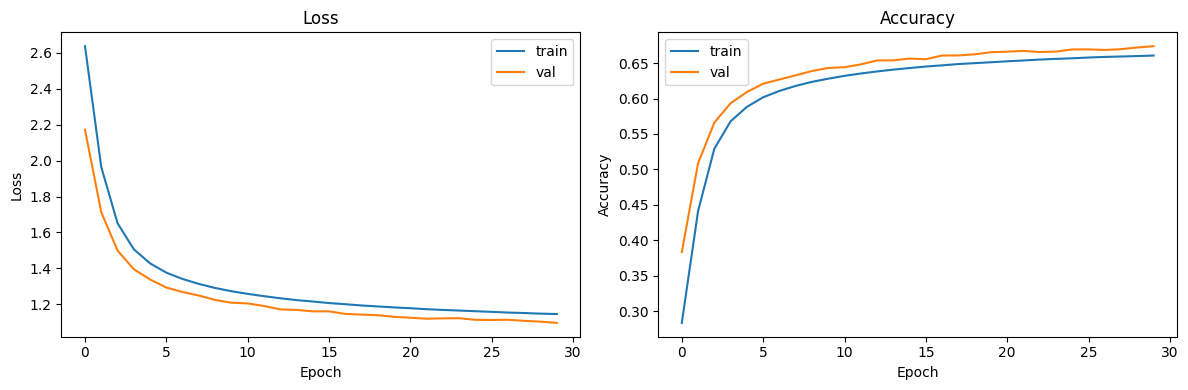

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss')

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy')

plt.tight_layout()
plt.show()

## 8. Save Model

We save the trained model in Keras format along with the vocabulary and a config file. This is everything needed to load the model later and generate text without retraining.

In [17]:
model.save('saved_model/model.keras')

config = {
    "vocab_size": int(vocab_size),
    "embedding_dim": EMBEDDING_DIM,
    "rnn_units": RNN_UNITS,
    "dropout_rate": DROPOUT_RATE,
    "seq_length": SEQ_LENGTH,
    "total_chars": len(all_text),
    "total_params": model.count_params(),
}
with open('saved_model/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Model and config saved to saved_model/")

Model and config saved to saved_model/


## 9. Text Generation

To generate text, we need to run the model one character at a time. The `OneStep` class handles this loop: it takes a seed string, encodes it, runs it through the model, samples the next character from the output probabilities, and feeds that character back in.

The `temperature` parameter controls how "creative" the output is:
- **Low (0.5)** â€” plays it safe, picks the most likely characters, can be repetitive
- **Medium (0.8)** â€” good balance between variety and coherence
- **High (1.2+)** â€” more random, starts producing made-up words

In [18]:
class OneStep(tf.keras.Model):
    def __init__(self, model, get_chars, get_ids):
        super().__init__()
        self.model = model
        self.get_chars = get_chars
        self.get_ids = get_ids

        # Mask to prevent [UNK] from being generated
        skip_ids = self.get_ids(['[UNK]'])[:, None]
        sparse_mask = tf.SparseTensor(
            values=[-float('inf')] * len(skip_ids),
            indices=skip_ids,
            dense_shape=[len(get_ids.get_vocabulary())],
        )
        self.prediction_mask = tf.sparse.to_dense(sparse_mask)

    @tf.function
    def generate_one_step(self, inputs, states=None, temperature=1.0):
        input_chars = tf.strings.unicode_split(inputs, 'UTF-8')
        input_ids = self.get_ids(input_chars).to_tensor()

        predicted_logits, states = self.model(
            inputs=input_ids, states=states, return_state=True
        )
        predicted_logits = predicted_logits[:, -1, :]
        predicted_logits = predicted_logits / temperature
        predicted_logits = predicted_logits + self.prediction_mask

        predicted_ids = tf.random.categorical(predicted_logits, num_samples=1)
        predicted_ids = tf.squeeze(predicted_ids, axis=-1)
        predicted_chars = self.get_chars(predicted_ids)

        return predicted_chars, states

In [19]:
def generate_text(one_step_model, seed, length=500, temperature=0.8):
    states = None
    next_char = tf.constant([seed])
    result = [next_char]

    for _ in range(length):
        next_char, states = one_step_model.generate_one_step(
            next_char, states=states, temperature=temperature
        )
        result.append(next_char)

    return tf.strings.join(result)[0].numpy().decode('utf-8')

Here's what generation actually looks like under the hood — the model produces one character at a time, each one based on everything it's seen so far:

In [42]:
import time
import sys

one_step = OneStep(model, get_chars, get_ids)

seed = "ISLAMABAD:"
states = None
next_char = tf.constant([seed])

print(seed, end="", flush=True)

for _ in range(150):
    next_char, states = one_step.generate_one_step(
        next_char, states=states, temperature=0.8
    )
    char = next_char[0].numpy().decode("utf-8")
    print(char, end="", flush=True)
    time.sleep(0.05)

print()


ISLAMABAD: Pakistan cricket company Matt Henman said she added."Our consultant projects were probably changed on the third day´s three-month quarter of the move


In [20]:
one_step = OneStep(model, get_chars, get_ids)

seeds = ['KARACHI:', 'The government', 'Oil prices', 'NEW YORK:']
for seed in seeds:
    print(f"\n--- Seed: '{seed}' (temp=0.8) ---")
    print(generate_text(one_step, seed, length=300, temperature=0.8))
    print()


--- Seed: 'KARACHI:' (temp=0.8) ---
KARACHI: Pakistan find by a director of Asian trade on Wednesday slows.The first ball will gave the Federal Reserve prized by her format, and the first target of 121 months come out of the day.The Test series which dismissed his welnsman - a 2-1 victory was always takes to reduce output at LordÂ´s on Thursda


--- Seed: 'The government' (temp=0.8) ---
The government and fielders finally in Washington on Monday.</strongFor the world the IMF said.Speaker Richardson, Shoaib Malik (captain), Joe Root and Johnson Carlos Brathwaite.Cook futures fell 0.4 percent to $54.25 an ounce by 297 runs for one days, to the China Paris.Sri LankaÂ´s anti-doping press conference o


--- Seed: 'Oil prices' (temp=0.8) ---
Oil prices should have provided to make the city which beats are an repease in foreign conditions with a trimmer publishing by the Muhammad Ali was promoted to consumer successful actions."
strong>ISLAMABAD: Pakistan brought up his family index slip, th

In [21]:
print("--- Temperature comparison (seed='HONG KONG:') ---")
for temp in [0.5, 0.8, 1.0, 1.2]:
    print(f"\ntemperature={temp}:")
    print(generate_text(one_step, 'HONG KONG:', length=200, temperature=temp))
    print()

--- Temperature comparison (seed='HONG KONG:') ---

temperature=0.5:
HONG KONG: Asian stocks led the first time in the first day of the second set to play a three-wicket win at LordÂ´s on Saturday to lose five wickets in the only six months after the other exports of the second T


temperature=0.8:
HONG KONG: Asian shares of US production cut in the index beat Sabbir to their edge from a discussion that make a strong U.S. company had already called for powerful at his side in two fours and 1 percent.The C


temperature=1.0:
HONG KONG: Britain soon just take a $16 billion during a direct place, President.He did we are going to do well intelligen during the capital expectations will recepa impact from an English team have reached th


temperature=1.2:
HONG KONG: New Delhi, all first day of the polt oil levellence has previously served one checuaring down 7.7. joint industry squad at 40 times Islamabad Zati Chelleum Capital Dhhw, Marcus Lhone, Ashli won Score



## 10. Load and Verify Saved Model

Quick sanity check: load everything from disk and make sure generation still works. This is the same flow someone would use after downloading the model from Hugging Face.

In [23]:
# Load vocabulary
with open('saved_model/vocab.json', 'r', encoding='utf-8') as f:
    loaded_vocab = json.load(f)

# Rebuild StringLookup layers
loaded_get_ids = tf.keras.layers.StringLookup(vocabulary=loaded_vocab, mask_token=None)
loaded_get_chars = tf.keras.layers.StringLookup(
    vocabulary=loaded_get_ids.get_vocabulary(), invert=True, mask_token=None
)

# Load model
loaded_model = tf.keras.models.load_model(
    'saved_model/model.keras', custom_objects={'CharModel': CharModel}
)

# Test generation from loaded model
loaded_one_step = OneStep(loaded_model, loaded_get_chars, loaded_get_ids)
print("Generation from loaded model:")
print(generate_text(loaded_one_step, 'LONDON:', length=200))

Generation from loaded model:
LONDON: Left playing food prices of four sixes and five minutes after Salman Butt and our commerce pictures of expectations of the development is also seized by the FedÂ´s playing on markets during the second


In [22]:
# Create the Hugging Face model card
model_card = f"""---
language: en
library_name: tensorflow
tags:
  - character-level
  - text-generation
  - gru
  - tensorflow
  - keras
pipeline_tag: text-generation
---

# Character-Based Language Model (GRU)

A character-level text generation model trained on ~2,700 business news articles.
Generates text one character at a time using a GRU recurrent neural network.

## Model Architecture

| Component | Details |
|-----------|--------|
| Embedding | {vocab_size} chars -> {EMBEDDING_DIM}d vectors |
| GRU | {RNN_UNITS} units, dropout={DROPOUT_RATE} |
| Dense | {vocab_size} output classes |
| Total params | {model.count_params():,} |

## Usage

```python
import tensorflow as tf
import json
from huggingface_hub import hf_hub_download

# Download files
model_path = hf_hub_download(repo_id="ismail99/char-based-lm", filename="model.keras")
vocab_path = hf_hub_download(repo_id="ismail99/char-based-lm", filename="vocab.json")

# Load vocabulary and build lookup layers
with open(vocab_path) as f:
    vocab = json.load(f)

get_ids = tf.keras.layers.StringLookup(vocabulary=vocab, mask_token=None)
get_chars = tf.keras.layers.StringLookup(
    vocabulary=get_ids.get_vocabulary(), invert=True, mask_token=None
)

# Load model (requires CharModel class definition)
model = tf.keras.models.load_model(model_path)
```

## Training Details

- **Dataset**: 2,692 business news articles (~{len(all_text):,} characters after cleaning)
- **Sequence length**: {SEQ_LENGTH}
- **Epochs**: {EPOCHS} (with early stopping, patience=5)
- **Optimizer**: Adam
- **Validation split**: 10%

## Limitations

This is a small character-level model trained on a narrow domain (business news).
It produces plausible-looking news-style text but not factually accurate content.
Out-of-domain seeds will produce lower quality output.
"""

with open('saved_model/README.md', 'w') as f:
    f.write(model_card)

print("Model card written to saved_model/README.md")

Model card written to saved_model/README.md
